In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.colors import LogNorm

import glob
import os
import csv
import ast

from scipy.stats import chi2_contingency
from math import sqrt
import calendar

In [2]:
from pathlib import Path

DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)

## Functions 

### saidi/saifi plot   

In [3]:
## revised -> one marker legend 

In [4]:
def plot_saidi_saifi_dual_boxplot_with_custom_markers(
    df,
    year_col="Year",
    dpi=150,
    saidi_col="SAIDI",
    saifi_col="SAIFI",
    years=(2022, 2023),
    saidi_color="mediumblue",
    saifi_color="salmon",
    xlabel="Year",
    saidi_ylabel="SAIDI",
    saifi_ylabel="SAIFI",
    tick_fontsize=12,
    label_fontsize=16,
    figsize=(9, 7),
    legend_loc='upper left',
    legend_bbox=(1.1, 1),
    box_width=0.3,
    save_path=None,
    saidi_marker_values=None,   # list, one value per year
    saifi_marker_values=None,   # list, one value per year
    saidi_marker_style="o",     # single style
    saifi_marker_style="D"      # single style
):
    import matplotlib.pyplot as plt
    import matplotlib.lines as mlines
    import numpy as np

    # --- Prepare data ---
    saidi_data = [df[df[year_col] == yr][saidi_col] for yr in years]
    saifi_data = [df[df[year_col] == yr][saifi_col] for yr in years]
    x = np.arange(len(years))

    fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
    ax2 = ax1.twinx()

    # --- Boxplots ---
    bp_saidi = ax1.boxplot(
        saidi_data,
        positions=x - box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=2)
    )

    bp_saifi = ax2.boxplot(
        saifi_data,
        positions=x + box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=2)
    )

    # --- Color boxes ---
    for box in bp_saidi["boxes"]:
        box.set_facecolor(saidi_color)

    for box in bp_saifi["boxes"]:
        box.set_facecolor(saifi_color)

    # --- Plot markers for BOTH years (same style) ---
    if saidi_marker_values is not None:
        for i in range(len(years)):
            ax1.scatter(
                x[i] - box_width / 2,
                saidi_marker_values[i],
                color=saidi_color,
                marker=saidi_marker_style,
                s=120,
                zorder=5
            )

    if saifi_marker_values is not None:
        for i in range(len(years)):
            ax2.scatter(
                x[i] + box_width / 2,
                saifi_marker_values[i],
                color=saifi_color,
                marker=saifi_marker_style,
                s=120,
                zorder=5
            )

    # --- Axis formatting ---
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(y) for y in years],
                        fontsize=tick_fontsize,
                        fontweight="bold")

    ax1.set_xlabel(xlabel,
                   fontsize=label_fontsize,
                   fontweight="bold",
                   labelpad=15)

    ax1.set_ylabel(saidi_ylabel,
                   fontsize=label_fontsize,
                   fontweight="bold",
                   labelpad=15,
                   color=saidi_color)

    ax2.set_ylabel(saifi_ylabel,
                   fontsize=label_fontsize,
                   fontweight="bold",
                   labelpad=15,
                   color=saifi_color)

    # --- Spine styling ---
    ax1.spines["left"].set_color(saidi_color)
    ax1.spines["left"].set_linewidth(1.2)
    ax1.tick_params(axis="y",
                    colors=saidi_color,
                    labelsize=tick_fontsize,
                    width=2)

    ax2.spines["right"].set_color(saifi_color)
    ax2.spines["right"].set_linewidth(1.2)
    ax2.tick_params(axis="y",
                    colors=saifi_color,
                    labelsize=tick_fontsize,
                    width=2)

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    ax1.tick_params(axis="x",
                    labelsize=tick_fontsize,
                    color='black',
                    width=1.5)

    # --- CLEAN Legend (only one per metric) ---
    legend_handles = [
        mlines.Line2D([], [], color="black", linewidth=2, label="Median"),
        mlines.Line2D([], [], color=saidi_color,
                      marker=saidi_marker_style,
                      linestyle="None",
                      markersize=10,
                      label="SAIDI"),
        mlines.Line2D([], [], color=saifi_color,
                      marker=saifi_marker_style,
                      linestyle="None",
                      markersize=10,
                      label="SAIFI")
    ]

    ax1.legend(handles=legend_handles,
               fontsize=tick_fontsize,
               loc=legend_loc,
               bbox_to_anchor=legend_bbox)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [5]:
import calendar
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_boxplot(
    df,
    x_col,
    y_col,
    y_label,
    hue_col=None,
    figsize=(7, 6),
    showfliers=False,
    tick_fontsize=12,
    tick_bold=False,
    legend_fontsize=16,
    august_first=True,
    xlabel=None,
    custom_legend_labels=None,
    legend_bbox=(0.9, 1),
    legend_loc="upper left", 
    save_path = None
):
    # ---- Copy to avoid modifying original ----
    plot_df = df.copy()

    # ---- Handle month column ----
    if x_col.lower() == "month_num":

        plot_df[x_col] = plot_df[x_col].apply(
            lambda x: calendar.month_abbr[int(x)]
        )

        if august_first:
            month_order = [
                'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
                'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul'
            ]
        else:
            month_order = list(calendar.month_abbr[1:])

        plot_df[x_col] = pd.Categorical(
            plot_df[x_col],
            categories=month_order,
            ordered=True
        )

        plot_df = plot_df.sort_values(x_col)
        order = month_order
    else:
        order = None

    # ---- Enforce CESI ordering ----
    hue_order = None
    if hue_col == "cesi_level":
        hue_order = ["Low", "Medium", "High"]

    # ---- Color palettes ----
    palette = None

    if hue_col == "cesi_level":
        palette = {
            "Low": "#2ca02c",
            "Medium": "#ff7f0e",
            "High": "#d62728"
        }

    elif hue_col == "dur":
        # palette = {
        #     1.5: "#1f77b4",
        #     2: "#9467bd",     # purple

        #     2.5: "#9467bd",
        #     4.0: "#8c564b"
        # }
        # palette = {
        #     1.5: "#8ecae6",  # light blue
        #     2.0: "#219ebc",  # blue
        #     2.5: "#ffb703",  # amber
        #     4.0: "#fb8500"   # strong orange
        # }
        palette = {
            1.5: "#0072B2",
            2.0: "#009E73",
            2.5: "#E69F00",
            4.0: "#D55E00"
        }

    elif hue_col is not None:
        palette = sns.color_palette(
            "Set2",
            n_colors=plot_df[hue_col].nunique()
        )

    # ---- Plot ----
    plt.figure(figsize=figsize)
    ax = plt.gca()

    sns.boxplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        order=order,
        hue_order=hue_order,
        showfliers=showfliers,
        palette=palette,
        ax=ax
    )

    # ---- Labels ----
    ax.set_xlabel(
        xlabel if xlabel is not None else x_col,
        fontsize=18,
        fontweight='bold',
        labelpad=15
    )
    ax.set_ylabel(
        y_label,
        fontsize=18,
        fontweight='bold',
        labelpad=15
    )

    # ---- Tick styling ----
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold' if tick_bold else 'normal')

    # ---- Spine styling ----
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # ---- Legend (parameterized position) ----
    if hue_col is not None:
        handles, labels = ax.get_legend_handles_labels()

        if custom_legend_labels is not None:
            label_map = {str(k): v for k, v in custom_legend_labels.items()}
            labels = [label_map.get(l, l) for l in labels]

        ax.legend(
            handles,
            labels,
            title="",
            fontsize=legend_fontsize,
            frameon=False,
            bbox_to_anchor=legend_bbox,
            loc=legend_loc
        )

    plt.tight_layout()

    # ---- Save figure if path is provided ----
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

In [6]:
import pandas as pd

def process_all_eas_outages(df_2022, df_2023, value_col):
    """
    Process 2022 and 2023 outage data by ea_code9ch, fill missing months, 
    and calculate monthly averages across EAs.
    
    Parameters
    ----------
    df_2022 : pd.DataFrame
        2022 outage data with columns ['ea_code9ch', 'Year_Month', 'month_num', value_col]
    df_2023 : pd.DataFrame
        2023 outage data
    value_col : str
        Column to average (e.g., '1to4hr_outage_events')
        
    Returns
    -------
    avg_outages : pd.DataFrame
        Average outages per month across EAs, with filled missing months
    """
    
    # Concatenate both years
    df_all = pd.concat([df_2022, df_2023], ignore_index=True)
    
    # Convert Year_Month to datetime period
    df_all['year_month'] = pd.to_datetime(df_all['Year_Month']).dt.to_period('M')
    
    # Full list of years and months
    years = sorted(df_all['year_month'].dt.year.unique())
    months = range(1, 13)
    
    # Full grid of EA x year x month
    full_index = pd.MultiIndex.from_product(
        [df_all['ea_code9ch'].unique(), years, months],
        names=['ea_code9ch', 'year', 'month_num']
    )
    
    # Set numeric column
    numeric_cols = [value_col]
    df_numeric = df_all.copy()
    df_numeric['year'] = df_numeric['year_month'].dt.year
    df_numeric = df_numeric.set_index(['ea_code9ch', 'year', 'month_num'])[numeric_cols]
    
    # Reindex to fill missing months with 0
    df_filled = df_numeric.reindex(full_index, fill_value=0).reset_index()
    
    # Optional: rebuild Year_Month column
    df_filled['Year_Month'] = pd.to_datetime(
        df_filled['year'].astype(str) + '-' + df_filled['month_num'].astype(str)
    ).dt.to_period('M')
    
    # Compute monthly average across EAs
    avg_outages = df_filled.groupby('month_num')[value_col].mean().reset_index()
    avg_outages = avg_outages.rename(columns={value_col: 'avg_outage_events'})
    
    return df_filled, avg_outages

In [7]:
import pandas as pd
import numpy as np

def process_outages_by_duration(
    df,
    min_dur=60,
    max_dur=240,
    outage_col='outage_events',
    new_col_name='1to4hr_outage_events',
    site_to_ea_map=None
):
    """
    Process outages by duration, aggregate by site/month, and optionally map to EAs.

    Parameters
    ----------
    df : pd.DataFrame
        Input outage data with at least ['site_id', 'time', outage_col, 'outage_mins'].
    min_dur : int
        Minimum duration (inclusive) in minutes.
    max_dur : int
        Maximum duration (exclusive) in minutes.
    outage_col : str
        Column name of the original outage events.
    new_col_name : str
        Column name for adjusted outage events.
    site_to_ea_map : pd.DataFrame or None
        DataFrame mapping site_id to ea_code9ch. Must have ['site_id', 'ea_code9ch'].
    
    Returns
    -------
    geo_dur_grouped_22 : pd.DataFrame
        Processed outages for 2022.
    geo_dur_grouped_23 : pd.DataFrame
        Processed outages for 2023.
    """
    
    df_proc = df.copy()
    
    # Filter and adjust outages
    mask = (df_proc['outage_mins'] >= min_dur) & (df_proc['outage_mins'] < max_dur)
    
    df_proc['outage_mins_dur'] = np.where(
        mask,
        np.floor(df_proc['outage_mins'] / 60).astype(int),
        0
    )
    
    df_proc[new_col_name] = np.where(mask, df_proc[outage_col], 0)
    
    # Extract date info
    df_proc['Date'] = pd.to_datetime(df_proc['time']).dt.date
    df_proc['Year_Month'] = pd.to_datetime(df_proc['time']).dt.to_period('M').astype(str)
    df_proc['month_num'] = df_proc['time'].dt.month
    
    # Aggregate by site & month
    geo_dur_grouped = (
        df_proc
        .groupby(['site_id', 'Year_Month', 'month_num'])[[new_col_name]]
        .sum()
        .reset_index()
    )
    
    # Map EAs if mapping provided
    if site_to_ea_map is not None:
        geo_dur_grouped = geo_dur_grouped.merge(
            site_to_ea_map, on='site_id', how='left'
        )
        # Keep only relevant columns
        geo_dur_grouped = geo_dur_grouped[['ea_code9ch', 'site_id', 'Year_Month', 'month_num', new_col_name]]
    
    # Extract year
    geo_dur_grouped['Year'] = geo_dur_grouped['Year_Month'].str[:4]
    
    # Split years
    geo_dur_grouped_22 = geo_dur_grouped[geo_dur_grouped['Year'] == '2022'].copy()
    geo_dur_grouped_23 = geo_dur_grouped[geo_dur_grouped['Year'] == '2023'].copy()
    
    return geo_dur_grouped_22, geo_dur_grouped_23


### EA Names mapped  

In [8]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites  

### *** using new 'EAs_n_Sites' (6km) 

In [9]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [10]:
# merged_eas_sites['ea_code9ch'].nunique()

In [11]:
filtered_eas_sites_copy = merged_eas_sites

## Outage Workflow 

### PQR hourly data  

In [12]:
## 22 
pqr_hourly_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])
pqr_hourly_all = pqr_hourly_all[pqr_hourly_all['site_id'] != 0 ].reset_index(drop=True)

## Remove sites with > `10%` missing data & less than 24 months 

In [13]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

## remove those sites 
pqr_hourly_all = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

In [14]:
geo_pqr_all = pqr_hourly_all[['time', 'site_id', 'outage_events', 'outage_mins']].copy()

### Sites of interest 

In [15]:
sites_of_interest = geo_pqr_all['site_id'].unique().tolist()

### Global EAs & sites 

In [16]:
sites_eas_df = pd.read_csv(DATA_DIR / 'miscellaneous/grouped_sites_n_eas_df.csv')

# Safely convert string representations of lists to actual lists
sites_eas_df['site_id'] = sites_eas_df['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
sites_eas_exploded = sites_eas_df.explode('site_id').reset_index(drop=True)

### using 289 EAs 

In [17]:
merged_eas_sites = merged_eas_sites.rename(columns = {'Intersecting_Sites':'site_id'})

# Safely convert string representations of lists to actual lists
merged_eas_sites['site_id'] = merged_eas_sites['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_exploded = merged_eas_sites.explode('site_id').reset_index(drop=True)

In [18]:
# merged_eas_sites_exploded

### --- use the 214 TPLW EAs INSTEAD for uniformity 

In [19]:
tplw_ea_df = pd.read_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv')

In [20]:
list_tplw_eas = tplw_ea_df['ea_code9ch'].unique().tolist()

In [21]:
merged_eas_sites_TPLW = merged_eas_sites[ merged_eas_sites['ea_code9ch'].isin(list_tplw_eas) ].reset_index(drop=True)

In [22]:
# Safely convert string representations of lists to actual lists
merged_eas_sites_TPLW['site_id'] = merged_eas_sites_TPLW['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_TPLW_exploded = merged_eas_sites_TPLW.explode('site_id').reset_index(drop=True)

In [23]:
# merged_eas_sites_TPLW_exploded

In [24]:
merged_eas_sites_TPLW_exploded['ea_code9ch'].nunique()

214

## *--- PQR Metrics per Month ---*  

### 1to4hr outages -> EA level 

In [25]:
geo_dur_grouped_22, geo_dur_grouped_23 = process_outages_by_duration(
    geo_pqr_all,
    min_dur = 60,
    max_dur = 240,
    outage_col = 'outage_events',
    new_col_name = '1to4hr_outage_events',
    site_to_ea_map = merged_eas_sites_TPLW_exploded
)

### remove sites without outages  

In [26]:
# Remove sites with zero outages in 2022
geo_dur_grouped_22 = geo_dur_grouped_22[
    geo_dur_grouped_22.groupby('site_id')['1to4hr_outage_events'].transform('sum') > 0
].copy()


# Remove sites with zero outages in 2023
geo_dur_grouped_23 = geo_dur_grouped_23[
    geo_dur_grouped_23.groupby('site_id')['1to4hr_outage_events'].transform('sum') > 0
].copy()

geo_dur_grouped_22 = geo_dur_grouped_22.reset_index(drop=True)
geo_dur_grouped_23 = geo_dur_grouped_23.reset_index(drop=True)

### Average per EA, per year month 

In [27]:
## Total per EA and Year_Month 
ea_monthly_avg_22 = (
    geo_dur_grouped_22
    .groupby(['ea_code9ch', 'Year_Month', 'month_num'])['1to4hr_outage_events']
    .mean()
    .reset_index()
)

### 2023 

## Total per EA and Year_Month 
ea_monthly_avg_23 = (
    geo_dur_grouped_23
    .groupby(['ea_code9ch', 'Year_Month', 'month_num'])['1to4hr_outage_events']
    .mean()
    .reset_index()
)

In [28]:
outages_both_yrs_1_4hrs_EAs, ___ = process_all_eas_outages(
    df_2022 = ea_monthly_avg_22,
    df_2023 = ea_monthly_avg_23,
    value_col='1to4hr_outage_events'
)


avg_total_outages_per_month_1_4hrs_EAs = (
    outages_both_yrs_1_4hrs_EAs.groupby(['ea_code9ch', "month_num"], as_index=False)
          .agg(avg_outage_events=("1to4hr_outage_events", "mean"))
)

avg_total_outages_per_month_1_4hrs_EAs['dur'] = 2.5

### 4+ hour outages   

In [29]:
geo_dur_grouped_22, geo_dur_grouped_23 = process_outages_by_duration(
    geo_pqr_all,
    min_dur = 240,
    max_dur = 9999,
    outage_col = 'outage_events',
    new_col_name = '4+hr_outage_events',
    site_to_ea_map = merged_eas_sites_TPLW_exploded
)

### remove sites without outages  

In [30]:
# Remove sites with zero outages in 2022
geo_dur_grouped_22 = geo_dur_grouped_22[
    geo_dur_grouped_22.groupby('site_id')['4+hr_outage_events'].transform('sum') > 0
].copy()


# Remove sites with zero outages in 2023
geo_dur_grouped_23 = geo_dur_grouped_23[
    geo_dur_grouped_23.groupby('site_id')['4+hr_outage_events'].transform('sum') > 0
].copy()

geo_dur_grouped_22 = geo_dur_grouped_22.reset_index(drop=True)
geo_dur_grouped_23 = geo_dur_grouped_23.reset_index(drop=True)

### Average per EA, per year month 

In [31]:
## Total per EA and Year_Month 
ea_monthly_avg_22 = (
    geo_dur_grouped_22
    .groupby(['ea_code9ch', 'Year_Month', 'month_num'])['4+hr_outage_events']
    .mean()
    .reset_index()
)

### 2023 

## Total per EA and Year_Month 
ea_monthly_avg_23 = (
    geo_dur_grouped_23
    .groupby(['ea_code9ch', 'Year_Month', 'month_num'])['4+hr_outage_events']
    .mean()
    .reset_index()
)

In [32]:
outages_both_yrs_4hrs_plus_EAs, ___ = process_all_eas_outages(
    df_2022 = ea_monthly_avg_22,
    df_2023 = ea_monthly_avg_23,
    value_col='4+hr_outage_events'
)

avg_total_outages_per_month_4hrs_plus_EAs = (
    outages_both_yrs_4hrs_plus_EAs.groupby(['ea_code9ch', "month_num"], as_index=False)
          .agg(avg_outage_events=("4+hr_outage_events", "mean"))
)

avg_total_outages_per_month_4hrs_plus_EAs['dur'] = 4

### Concatenate 

In [33]:
from functools import reduce

# dfs = [avg_total_outages_per_month_1_4hrs_EAs, avg_total_outages_per_month_4hrs_plus_EAs]
dfs = [avg_total_outages_per_month_1_4hrs_EAs]

merged_outage_durations_EAs = pd.concat(dfs, ignore_index=True)

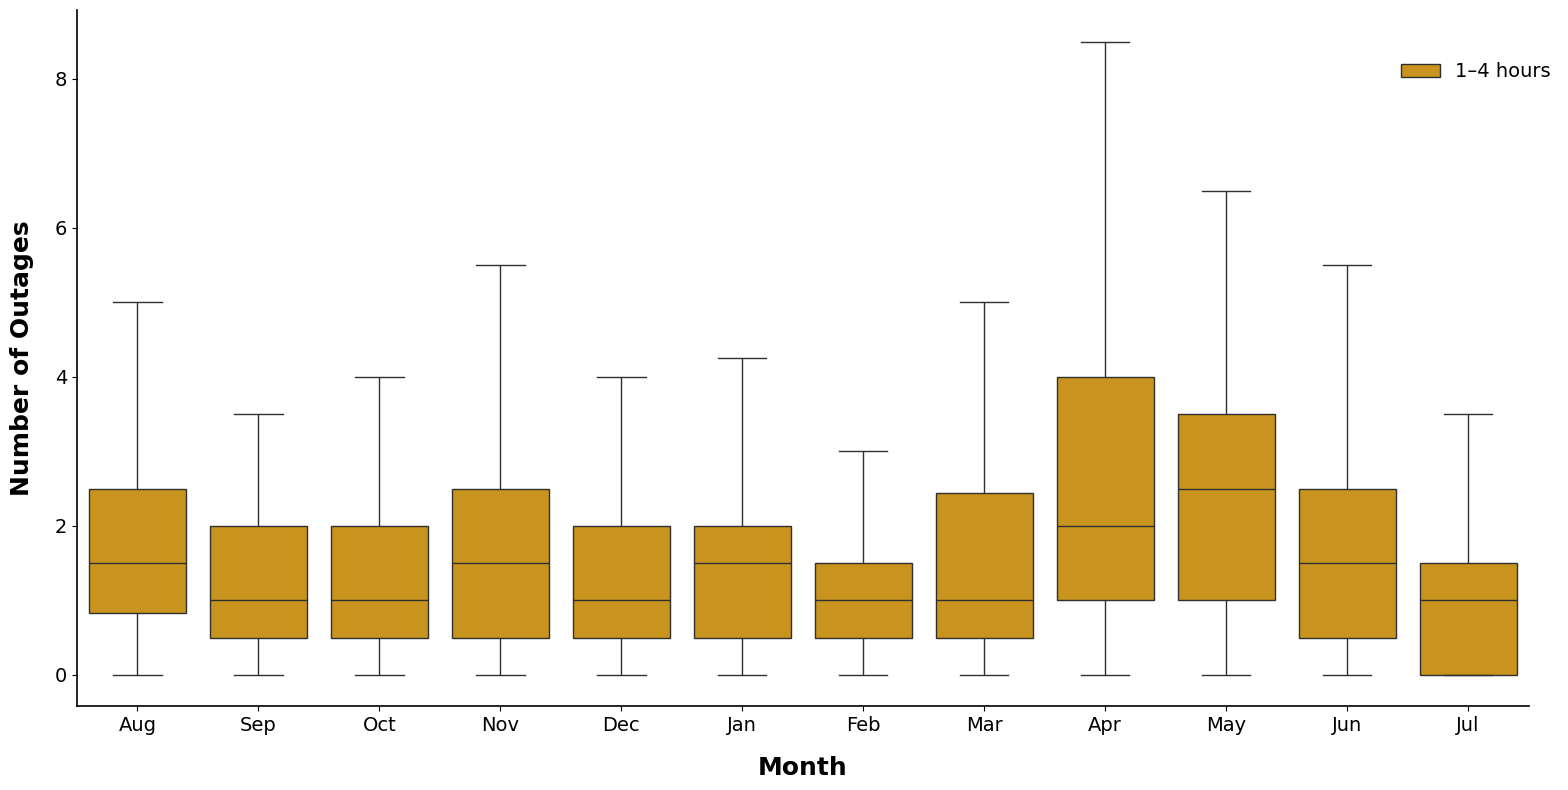

In [34]:
plot_boxplot(
    df=merged_outage_durations_EAs,
    x_col='month_num',
    y_col='avg_outage_events',
    y_label='Number of Outages',
    hue_col='dur',
    showfliers=False,
    tick_fontsize=14,
    tick_bold=False,
    legend_fontsize=14,
    august_first=True,     
    xlabel='Month',
    legend_bbox=(0.90, 0.95),
    legend_loc='upper left', 
    figsize = (16,8), 
    custom_legend_labels={
        2.5: "1–4 hours",
        # 4.0: "≥ 4 hours"
    }, 
    save_path=PLOTS_DIR / 'characterizing_outages_per_EA_1_4hrs.png'
)

In [35]:
1.748880/1.200085

1.457296774811784

In [36]:
merged_outage_durations_EAs.groupby(['dur'])['avg_outage_events'].describe()

,count,mean,std,min,25%,50%,75%,max
dur,,,,,,,,
2.5,2568.0,1.74888,2.002738,0.0,0.5,1.0,2.5,22.0


In [37]:
merged_outage_durations_EAs.groupby(['dur', 'month_num'])['avg_outage_events'].describe()

count      mean       std  min       25%  50%     75%   max
dur month_num                                                             
2.5 1          214.0  1.681269  1.944512  0.0  0.500000  1.5  2.0000  21.5
    2          214.0  1.320678  2.040669  0.0  0.500000  1.0  1.5000  19.5
    3          214.0  1.556464  1.705616  0.0  0.500000  1.0  2.4375  14.5
    4          214.0  2.636098  2.264094  0.0  1.000000  2.0  4.0000  16.0
    5          214.0  2.642329  2.230067  0.0  1.000000  2.5  3.5000  18.5
    6          214.0  1.929712  2.464974  0.0  0.500000  1.5  2.5000  21.5
    7          214.0  1.261877  1.831251  0.0  0.000000  1.0  1.5000  15.0
    8          214.0  1.834891  1.668035  0.0  0.833333  1.5  2.5000  11.5
    9          214.0  1.487344  1.527219  0.0  0.500000  1.0  2.0000  15.0
    10         214.0  1.411215  1.666775  0.0  0.500000  1.0  2.0000  14.0
    11         214.0  1.773170  1.868760  0.0  0.500000  1.5  2.5000  16.5
    12         214.0  1.451519  2.049362  0.0  0.500000  1.0  2.0000  22.0

## Comparing nLine SAIDI/SAIFI to utility SAIDI/SAIFI 

## SAIFI 

In [38]:
## read saifi df 
saifi_df = pd.read_csv(DATA_DIR / 'SAIDI_SAIFI/SAIFI-yearly-all-data.csv')

## extract year 
saifi_df['time'] = pd.to_datetime(saifi_df['time'])
saifi_df['Year'] = saifi_df['time'].dt.year

## filter 2022 & 2023 
saifi_df = saifi_df[saifi_df['Year'].isin([2022,2023])].reset_index(drop=True)

## keep only sites of interest 
saifi_df = saifi_df[ ( saifi_df['site_id'].isin(sites_of_interest) ) ].reset_index(drop=True)

## dfs for 2022 & 2023 
saifi_df_22 = saifi_df[saifi_df['Year'] == 2022].reset_index(drop=True)
saifi_df_23 = saifi_df[saifi_df['Year'] == 2023].reset_index(drop=True)

### SAIFI - '22 and '23 

In [39]:
## 2022 
merged_saifi_22 = merged_eas_sites_TPLW_exploded.merge(saifi_df_22, on ='site_id')
merged_saifi_22 = merged_saifi_22[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIFI', 'est_uncertainty']]

## 2023 
merged_saifi_23 = merged_eas_sites_TPLW_exploded.merge(saifi_df_23, on ='site_id')
merged_saifi_23 = merged_saifi_23[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIFI', 'est_uncertainty']]

## concat 
merged_saifi_all = pd.concat([merged_saifi_22, merged_saifi_23], ignore_index=True)

In [40]:
# merged_saifi_all.groupby('Year')[['SAIFI']].describe()

## SAIDI 

In [41]:
## read saifi df 
saidi_df = pd.read_csv(DATA_DIR / 'SAIDI_SAIFI/SAIDI-yearly-all-data.csv')

## extract year 
saidi_df['time'] = pd.to_datetime(saidi_df['time'])
saidi_df['Year'] = saidi_df['time'].dt.year

## filter 2022 & 2023 
saidi_df = saidi_df[saidi_df['Year'].isin([2022,2023])].reset_index(drop=True)

## keep only sites of interest 
saidi_df = saidi_df[ ( saidi_df['site_id'].isin(sites_of_interest) ) ].reset_index(drop=True)

## dfs for 2022 & 2023 
saidi_df_22 = saidi_df[saidi_df['Year'] == 2022].reset_index(drop=True)
saidi_df_23 = saidi_df[saidi_df['Year'] == 2023].reset_index(drop=True)

### SAIDI - '22 and '23 

In [42]:
## 2022 
merged_saidi_22 = merged_eas_sites_TPLW_exploded.merge(saidi_df_22, on ='site_id')
merged_saidi_22 = merged_saidi_22[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'est_uncertainty']]

## 2023 
merged_saidi_23 = merged_eas_sites_TPLW_exploded.merge(saidi_df_23, on ='site_id')
merged_saidi_23 = merged_saidi_23[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'est_uncertainty']]

## concat 
merged_saidi_all = pd.concat([merged_saidi_22, merged_saidi_23], ignore_index=True)

In [43]:
# merged_saidi_all.groupby('Year')[['SAIDI']].describe()

## SAIDI_SAIFI merged 

In [44]:
saidi_saifi_merged = pd.merge(merged_saidi_all, merged_saifi_all, on = ['time', 'Year', 'ea_code9ch', 'site_id', 'est_uncertainty'])

saidi_saifi_merged = saidi_saifi_merged[['time', 'Year', 'ea_code9ch', 'site_id', 'SAIDI', 'SAIFI']]

### SAIDI/SAIFI plot 

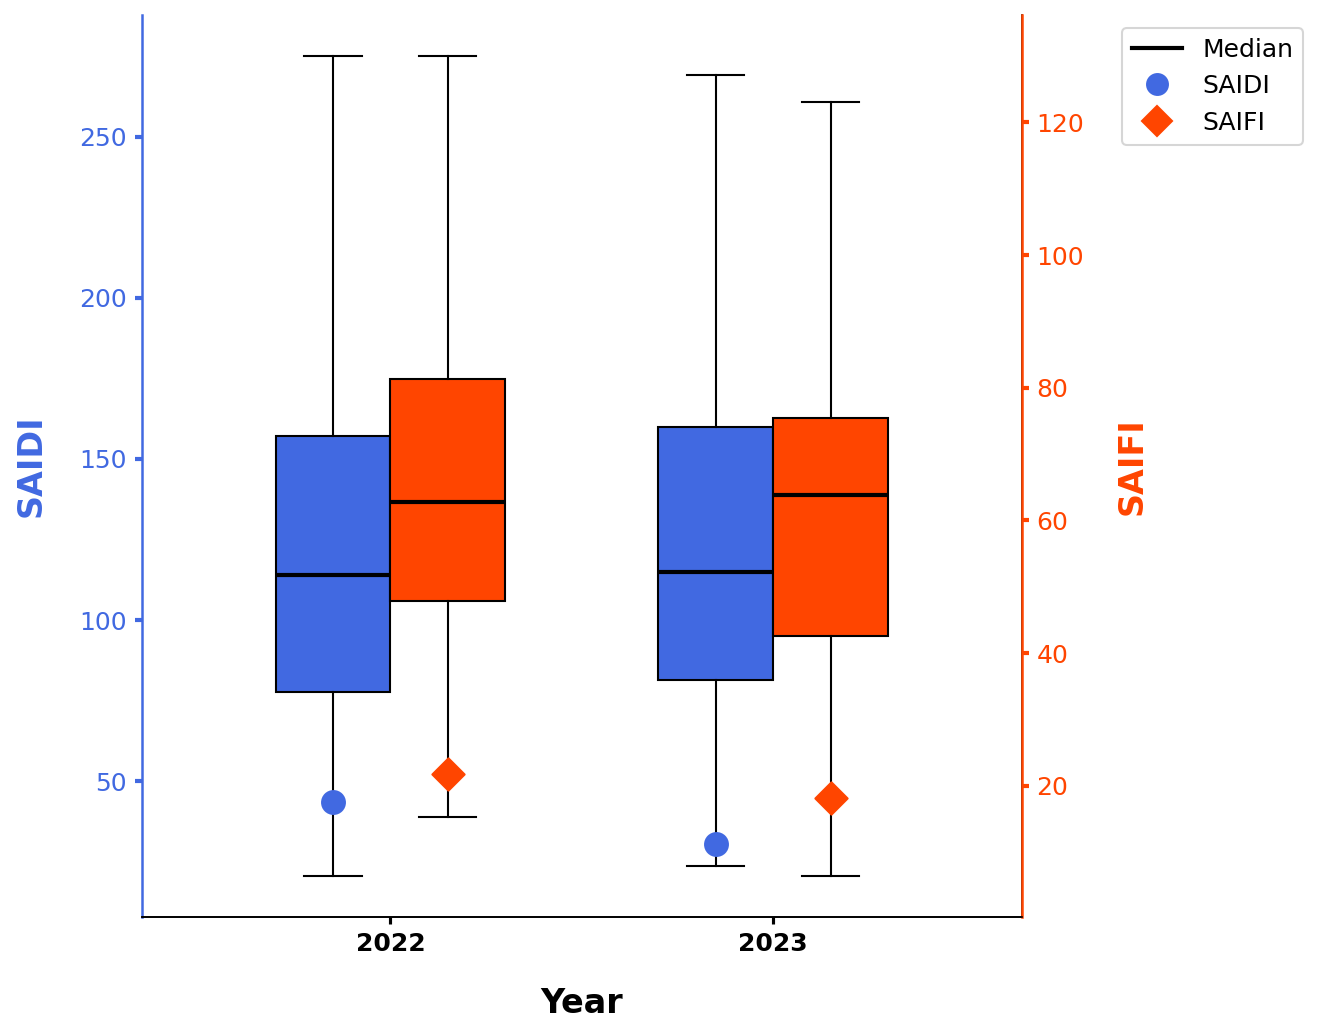

In [45]:
plot_saidi_saifi_dual_boxplot_with_custom_markers(
    saidi_saifi_merged,
    dpi = 150, 
    figsize=(9, 7),
    years=(2022, 2023),
    saidi_marker_values=[43.7, 30.7],
    saifi_marker_values=[21.8, 18.2],
    saidi_color="royalblue",
    saifi_color="orangered",
    # save_path=PLOTS_DIR / 'saidi_saifi_combined_boxplot_with_legend_v1.png'
)


In [46]:
def plot_saidi_saifi_dual_boxplot_with_custom_markers(
    df,
    year_col="Year",
    dpi=150,
    saidi_col="SAIDI",
    saifi_col="SAIFI",
    years=(2022, 2023),
    saidi_color="mediumblue",
    saifi_color="salmon",
    xlabel="Year",
    saidi_ylabel="SAIDI",
    saifi_ylabel="SAIFI",
    tick_fontsize=12,
    label_fontsize=16,
    figsize=(9, 7),
    legend_loc='upper left',
    legend_bbox=(1.1, 1),
    box_width=0.3,
    save_path=None,

    saidi_marker_values=None,
    saifi_marker_values=None,
    saidi_marker_style="o",
    saifi_marker_style="D",

    # Mean styling
    show_means=True,
    mean_marker='o',
    mean_markerfacecolor='white',
    mean_markeredgecolor='black',
    mean_markersize=8
):
    import matplotlib.pyplot as plt
    import matplotlib.lines as mlines
    import numpy as np

    # --- Prepare data ---
    saidi_data = [df[df[year_col] == yr][saidi_col].dropna() for yr in years]
    saifi_data = [df[df[year_col] == yr][saifi_col].dropna() for yr in years]

    x = np.arange(len(years))

    fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
    ax2 = ax1.twinx()

    # --- Boxplots ---
    bp_saidi = ax1.boxplot(
        saidi_data,
        positions=x - box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        showmeans=show_means,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(
            marker=mean_marker,
            markerfacecolor=mean_markerfacecolor,
            markeredgecolor=mean_markeredgecolor,
            markersize=mean_markersize
        )
    )

    bp_saifi = ax2.boxplot(
        saifi_data,
        positions=x + box_width / 2,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        showmeans=show_means,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(
            marker=mean_marker,
            markerfacecolor=mean_markerfacecolor,
            markeredgecolor=mean_markeredgecolor,
            markersize=mean_markersize
        )
    )

    # --- Color boxes ---
    for box in bp_saidi["boxes"]:
        box.set_facecolor(saidi_color)

    for box in bp_saifi["boxes"]:
        box.set_facecolor(saifi_color)

    # --- Plot custom markers ---
    if saidi_marker_values is not None:
        for i in range(len(years)):
            ax1.scatter(
                x[i] - box_width / 2,
                saidi_marker_values[i],
                color=saidi_color,
                marker=saidi_marker_style,
                s=120,
                zorder=5
            )

    if saifi_marker_values is not None:
        for i in range(len(years)):
            ax2.scatter(
                x[i] + box_width / 2,
                saifi_marker_values[i],
                color=saifi_color,
                marker=saifi_marker_style,
                s=120,
                zorder=5
            )

    # --- Axis formatting ---
    ax1.set_xticks(x)
    ax1.set_xticklabels(
        [str(y) for y in years],
        fontsize=tick_fontsize,
        fontweight="bold"
    )

    ax1.set_xlabel(
        xlabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15
    )

    ax1.set_ylabel(
        saidi_ylabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15,
        color=saidi_color
    )

    ax2.set_ylabel(
        saifi_ylabel,
        fontsize=label_fontsize,
        fontweight="bold",
        labelpad=15,
        color=saifi_color
    )

    # --- Spine styling ---
    ax1.spines["left"].set_color(saidi_color)
    ax1.spines["left"].set_linewidth(1.2)

    ax1.tick_params(
        axis="y",
        colors=saidi_color,
        labelsize=tick_fontsize,
        width=2
    )

    ax2.spines["right"].set_color(saifi_color)
    ax2.spines["right"].set_linewidth(1.2)

    ax2.tick_params(
        axis="y",
        colors=saifi_color,
        labelsize=tick_fontsize,
        width=2
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    ax1.tick_params(
        axis="x",
        labelsize=tick_fontsize,
        color='black',
        width=1.5
    )

    # --- Legend ---
    legend_handles = [
        mlines.Line2D(
            [], [],
            color="black",
            linewidth=2,
            label="Median"
        )
    ]

    if show_means:
        legend_handles.append(
            mlines.Line2D(
                [], [],
                color=mean_markeredgecolor,
                marker=mean_marker,
                markerfacecolor=mean_markerfacecolor,
                linestyle="None",
                markersize=mean_markersize,
                label="Mean"
            )
        )

    legend_handles.extend([
        mlines.Line2D(
            [], [],
            color=saidi_color,
            marker=saidi_marker_style,
            linestyle="None",
            markersize=10,
            label="SAIDI"
        ),
        mlines.Line2D(
            [], [],
            color=saifi_color,
            marker=saifi_marker_style,
            linestyle="None",
            markersize=10,
            label="SAIFI"
        )
    ])

    ax1.legend(
        handles=legend_handles,
        fontsize=tick_fontsize,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

### With the mean 

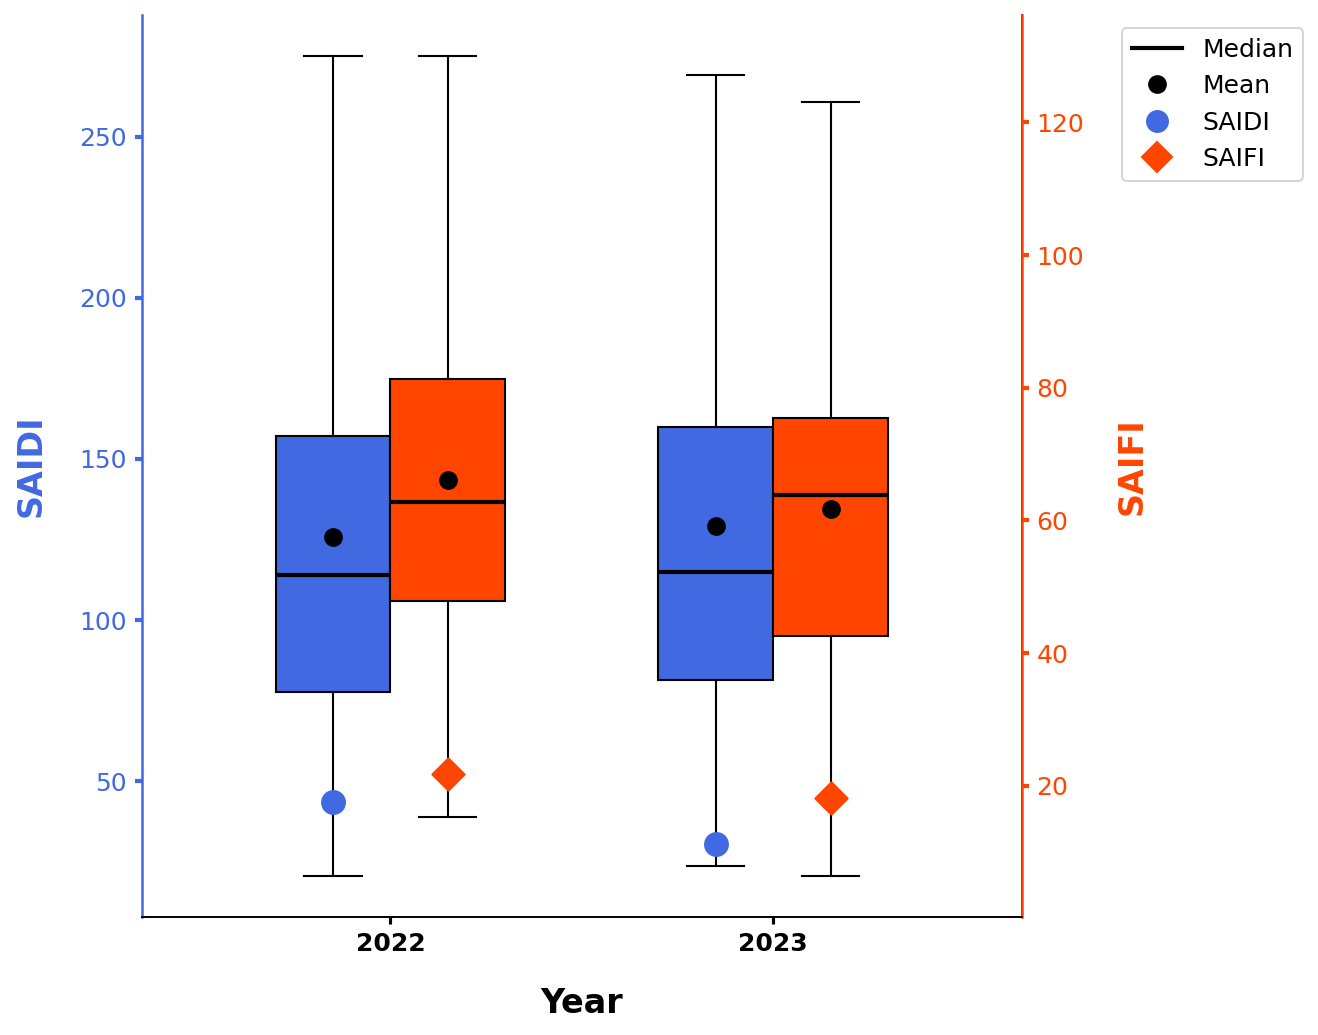

In [46]:
plot_saidi_saifi_dual_boxplot_with_custom_markers(
    saidi_saifi_merged,
    dpi = 150, 
    figsize=(9, 7),
    years=(2022, 2023),
    saidi_marker_values=[43.7, 30.7],
    saifi_marker_values=[21.8, 18.2],
    saidi_color="royalblue",
    saifi_color="orangered",
    show_means=True, 
    # mean_marker='s',
    mean_marker='o',
    mean_markerfacecolor='k',
    mean_markeredgecolor='k',
    save_path=PLOTS_DIR / 'supplementary/saidi_saifi_combined_boxplot_with_legend_v1.png'
)
